# TP3 — Attribution Multicanal — Lumina & Co

Dans `TP3 - KPIs par canal - Lumina & Co.ipynb`, on a vu que `display` et `social` totalisent 58 % des points de contact mais 0 conversion mesurée sur la colonne `converted` — parce que cette colonne, de fait, ne récompense que le **dernier** point de contact avant l'achat. Ce notebook compare explicitement le modèle **premier contact (first touch)** au modèle **dernier contact (last touch)**, pour voir ce que ça change à la lecture des canaux — et au budget qu'on déciderait de leur allouer.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DATA_DIR = "Lumina & Co - CRM"

campaigns = pd.read_csv(f"{DATA_DIR}/campaigns.csv")
touchpoints = pd.read_csv(f"{DATA_DIR}/touchpoints.csv")
touchpoints['timestamp'] = pd.to_datetime(touchpoints['timestamp'])
touchpoints['journey_prefix'] = touchpoints['journey_id'].str.split('_').str[0]

transactions = pd.read_csv(f"{DATA_DIR}/transactions.csv", usecols=['invoice_id','quantity','unit_price'])
transactions['line_total'] = transactions['quantity'] * transactions['unit_price']
invoice_total = transactions.groupby('invoice_id')['line_total'].sum()

print(f"{touchpoints['journey_id'].nunique():,} parcours uniques, "
      f"dont {(touchpoints['journey_prefix']=='conv').sum() and touchpoints[touchpoints['journey_prefix']=='conv']['journey_id'].nunique():,} ayant converti.")


214,897 parcours uniques, dont 94,366 ayant converti.


## Orientation — un coup d'œil aux parcours avant de comparer les modèles

### Combien de points de contact par parcours, en moyenne ?


In [2]:
journey_length = touchpoints.groupby('journey_id').agg(
    n_touchpoints_declare=('n_touchpoints', 'first'),
    n_lignes_visibles=('touchpoint_id', 'count'),
    prefix=('journey_prefix', 'first'),
)

print("Moyenne du nombre de points de contact déclaré (n_touchpoints), par type de parcours :")
print(journey_length.groupby('prefix')['n_touchpoints_declare'].mean())
print("\nMoyenne du nombre de lignes réellement visibles dans le fichier, par type de parcours :")
print(journey_length.groupby('prefix')['n_lignes_visibles'].mean())


Moyenne du nombre de points de contact déclaré (n_touchpoints), par type de parcours :
prefix
conv   4.72
exp    6.00
Name: n_touchpoints_declare, dtype: float64

Moyenne du nombre de lignes réellement visibles dans le fichier, par type de parcours :
prefix
conv   3.79
exp    6.00
Name: n_lignes_visibles, dtype: float64


Point d'attention repéré ici : pour les parcours **ayant converti**, le nombre de lignes réellement présentes dans le fichier (3,79 en moyenne) est **nettement inférieur** au nombre de points de contact déclaré (4,72). Ce n'est pas le cas pour les parcours n'ayant jamais converti (5,999 déclaré ≈ 6,00 visible). On creuse ce point juste après — il a un impact direct sur la fiabilité du modèle *first touch*.


### Quels canaux reviennent le plus souvent en première position ?

In [3]:
first_position = touchpoints[touchpoints['position'] == 1]
print("Canal en position 1 (toutes les parcours confondus, convertis ou non) :")
print((first_position['channel'].value_counts(normalize=True) * 100).round(1))


Canal en position 1 (toutes les parcours confondus, convertis ou non) :
channel
social        40.50
display       40.50
email          9.50
retargeting    9.40
Name: proportion, dtype: float64


**Seuls 4 canaux apparaissent jamais en position 1** : `display` (40,5 %) et `social` (40,5 %) très largement en tête, loin devant `email` (9,5 %) et `retargeting` (9,4 %). `affiliate`, `direct` et `search_paid` n'ouvrent **jamais** un parcours dans ce dataset — cohérent avec des canaux plutôt orientés "intention d'achat" que "découverte".


### Quels canaux reviennent le plus souvent juste avant la conversion ?

In [4]:
last_touch_rows = touchpoints[touchpoints['is_last_before_conversion'] == 1]
print("Canal juste avant l'achat (uniquement les parcours ayant converti) :")
print((last_touch_rows['channel'].value_counts(normalize=True) * 100).round(1))


Canal juste avant l'achat (uniquement les parcours ayant converti) :
channel
affiliate     28.60
retargeting   23.90
direct        17.80
email         15.20
search_paid   14.50
Name: proportion, dtype: float64


**`display` et `social` n'apparaissent JAMAIS en dernière position avant un achat (0 %)** — la répartition est totalement disjointe de celle du premier contact : `affiliate`, `retargeting`, `direct`, `email` et `search_paid` se partagent 100 % du crédit "dernier contact", et `display`/`social` 100 % du crédit "premier contact". Les deux groupes de canaux jouent des rôles structurellement différents dans le parcours — c'est le fil conducteur de tout ce notebook.


## Une limite de données à documenter avant d'aller plus loin

Le champ `n_touchpoints` de chaque parcours indique son nombre total de points de contact, mais le fichier ne contient pas toujours toutes les lignes correspondantes.


In [5]:
conv_journeys_stats = journey_length[journey_length['prefix'] == 'conv']
n_tronques = (conv_journeys_stats['n_lignes_visibles'] != conv_journeys_stats['n_touchpoints_declare']).sum()
print(f"Parcours ayant converti et tronqués (lignes manquantes) : {n_tronques:,} / {len(conv_journeys_stats):,} "
      f"({n_tronques/len(conv_journeys_stats)*100:.1f} %)")

# position minimale visible par parcours converti : doit être 1 pour permettre un vrai "first touch"
min_position = touchpoints[touchpoints['journey_prefix']=='conv'].groupby('journey_id')['position'].min()
n_sans_position1 = (min_position != 1).sum()
print(f"Parcours ayant converti SANS aucune ligne en position 1 visible : {n_sans_position1:,} / {len(min_position):,} "
      f"({n_sans_position1/len(min_position)*100:.1f} %)")


Parcours ayant converti et tronqués (lignes manquantes) : 59,444 / 94,366 (63.0 %)


Parcours ayant converti SANS aucune ligne en position 1 visible : 23,316 / 94,366 (24.7 %)


**Hypothèse la plus probable :** le fichier ne trace que les points de contact survenus après le début de la fenêtre d'observation (mi-2025). Un parcours entamé avant cette date perd donc ses premières étapes — un effet de **troncature à gauche**, qui touche uniquement les parcours ayant converti (les parcours `exp_*`, eux, ne sont jamais tronqués).

**Conséquence directe :** environ un quart des parcours convertis n'ont **aucune** ligne en position 1 exploitable. Le modèle *first touch* qu'on construit plus bas ne pourra donc s'appuyer que sur les parcours où cette première ligne existe — on le documente clairement au moment de le construire, plutôt que de le passer sous silence.


## `display` : ne pas le juger sur sa conversion directe

L'énoncé est explicite sur ce point, et les chiffres ci-dessus le confirment intégralement : `display` capte 40,5 % des premiers contacts mais 0 % des derniers contacts avant achat. Le juger avec un modèle *dernier contact* (comme le fait implicitement la colonne `converted`, vue dans le notebook KPI) revient à lui donner un CPA infini et un ROAS nul — alors qu'il assure, avec `social`, la quasi-totalité de la découverte initiale des parcours qui finissent par convertir. Le "classement" de `display` dépend donc entièrement du modèle d'attribution choisi — pas de sa vraie contribution.


## `primary_channel` : performance ou volume ?

`campaigns.csv` indique un `primary_channel` par campagne. Désigne-t-il le canal le plus performant, ou autre chose ?


In [6]:
volume_leader = (touchpoints.groupby(['campaign_name', 'channel']).size()
                 .reset_index(name='n_touchpoints')
                 .sort_values('n_touchpoints', ascending=False)
                 .drop_duplicates('campaign_name')
                 .rename(columns={'channel': 'canal_le_plus_present'}))

comparison = campaigns[['campaign_name', 'primary_channel']].merge(
    volume_leader[['campaign_name', 'canal_le_plus_present']], on='campaign_name')
comparison['primary_channel_est_le_plus_present'] = comparison['primary_channel'] == comparison['canal_le_plus_present']
comparison


,campaign_name,primary_channel,canal_le_plus_present,primary_channel_est_le_plus_present
0,Back_to_School,social,social,True
1,Black_Friday,display,display,True
2,Spring_Launch,display,display,True
3,Summer_Sale,display,display,True
4,Valentine,display,display,True
5,Winter_Promo,display,display,True


**`primary_channel` correspond exactement, sur les 6 campagnes, au canal ayant généré le plus de points de contact** — c'est donc un indicateur de **volume/poids budgétaire**, pas de performance. Sur 5 des 6 campagnes, c'est `display` — le même canal qui, on vient de le voir, n'apparaît jamais en dernier contact avant achat. Présenter `primary_channel` comme "le canal qui a fait le travail" serait donc trompeur.


## Implémentation des deux modèles heuristiques

### Modèle *last touch* — 100 % du crédit au dernier point de contact

C'est très exactement ce qu'on a déjà calculé dans le notebook KPI via la colonne `converted` (puisqu'elle ne s'active que sur le dernier point de contact) — on le recalcule ici sous une forme homogène pour la comparaison finale.


In [7]:
conversions = touchpoints[touchpoints['converted'] == 1].copy()
conversions['invoice_id_str'] = conversions['invoice_id'].astype(int).astype(str)
conversions['revenue'] = conversions['invoice_id_str'].map(invoice_total)

last_touch = conversions.groupby('channel').agg(n_conversions=('touchpoint_id', 'count'), revenue=('revenue', 'sum'))
last_touch['pct_conversions'] = last_touch['n_conversions'] / last_touch['n_conversions'].sum() * 100
last_touch['pct_revenue'] = last_touch['revenue'] / last_touch['revenue'].sum() * 100
last_touch.sort_values('pct_conversions', ascending=False)


,n_conversions,revenue,pct_conversions,pct_revenue
channel,,,,
affiliate,26979,"5,313,106.12",28.59,28.87
retargeting,22563,"4,455,952.61",23.91,24.21
direct,16803,"3,204,574.65",17.81,17.41
email,14355,"2,603,351.06",15.21,14.15
search_paid,13666,"2,824,693.39",14.48,15.35


### Modèle *first touch* — 100 % du crédit au premier point de contact

Pour chaque parcours ayant converti, on prend le canal de sa ligne `position == 1` (quand elle est visible — voir la limite documentée plus haut), puis on lui attribue 100 % du crédit de la conversion finale de ce parcours.


In [8]:
conv_journeys = touchpoints[touchpoints['journey_prefix'] == 'conv']
first_rows = (conv_journeys[conv_journeys['position'] == 1]
              [['journey_id', 'channel']].rename(columns={'channel': 'first_channel'}))

print(f"Parcours convertis exploitables pour le first touch : {len(first_rows):,} / "
      f"{conv_journeys['journey_id'].nunique():,} "
      f"({len(first_rows)/conv_journeys['journey_id'].nunique()*100:.1f} %) — le reste est exclu, faute de 1re ligne visible.")

conv_revenue = conversions[['journey_id', 'revenue']]
first_touch_df = first_rows.merge(conv_revenue, on='journey_id', how='left')

first_touch = first_touch_df.groupby('first_channel').agg(n_conversions=('journey_id', 'count'), revenue=('revenue', 'sum'))
first_touch['pct_conversions'] = first_touch['n_conversions'] / first_touch['n_conversions'].sum() * 100
first_touch['pct_revenue'] = first_touch['revenue'] / first_touch['revenue'].sum() * 100
first_touch.sort_values('pct_conversions', ascending=False)


Parcours convertis exploitables pour le first touch : 71,050 / 94,366 (75.3 %) — le reste est exclu, faute de 1re ligne visible.


,n_conversions,revenue,pct_conversions,pct_revenue
first_channel,,,,
display,35713,"6,958,347.34",50.26,50.15
social,35337,"6,915,951.17",49.74,49.85


### Comparaison côte à côte

In [9]:
comparison_pct = pd.DataFrame({
    'last_touch (% conversions)': last_touch['pct_conversions'],
    'first_touch (% conversions)': first_touch['pct_conversions'],
}).fillna(0).round(1)

comparison_val = pd.DataFrame({
    'last_touch (revenu €)': last_touch['revenue'],
    'first_touch (revenu €)': first_touch['revenue'],
}).fillna(0).round(0)

print("Répartition en % des conversions :")
display(comparison_pct.sort_values('last_touch (% conversions)', ascending=False))
print("\nRépartition en valeur (revenu attribué, €) :")
display(comparison_val.sort_values('last_touch (revenu €)', ascending=False))


Répartition en % des conversions :


,last_touch (% conversions),first_touch (% conversions)
affiliate,28.60,0.00
retargeting,23.90,0.00
direct,17.80,0.00
email,15.20,0.00
search_paid,14.50,0.00
display,0.00,50.30
social,0.00,49.70



Répartition en valeur (revenu attribué, €) :


,last_touch (revenu €),first_touch (revenu €)
affiliate,"5,313,106.00",0.00
retargeting,"4,455,953.00",0.00
direct,"3,204,575.00",0.00
search_paid,"2,824,693.00",0.00
email,"2,603,351.00",0.00
display,0.00,"6,958,347.00"
social,0.00,"6,915,951.00"


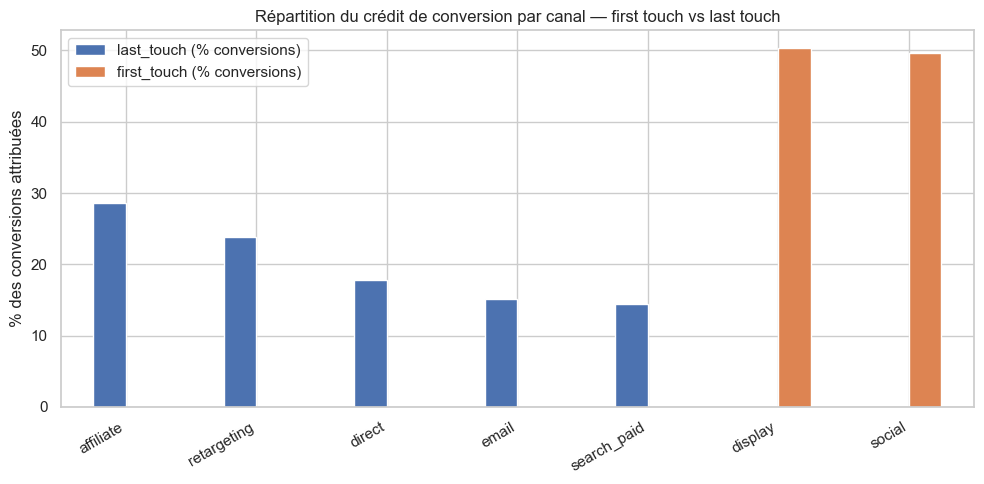

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
comparison_pct.sort_values('last_touch (% conversions)', ascending=False).plot(kind='bar', ax=ax)
ax.set_ylabel("% des conversions attribuées")
ax.set_title("Répartition du crédit de conversion par canal — first touch vs last touch")
ax.legend(title=None)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


**Les deux modèles se partagent des canaux totalement disjoints.** Le *last touch* attribue 100 % du crédit à `affiliate`, `retargeting`, `direct`, `email` et `search_paid` — et 0 % à `display`/`social`. Le *first touch* fait l'inverse exact : 100 % à `display` et `social`, 0 % partout ailleurs. Ce n'est pas un hasard : ça confirme, au niveau du modèle de budget, ce qu'on observait déjà sur les positions brutes plus haut.


## Analyse

**Si le CMO basait ses décisions budgétaires uniquement sur le last touch**, `display` et `social` — qui à eux deux génèrent 58 % de tous les points de contact et portent 100 % de la découverte initiale des parcours convertis — **seraient totalement sous-investis** : sur le papier, ils auraient un ROAS nul et un CPA infini (vu dans le notebook KPI), un signal qui pousserait à couper leur budget alors qu'ils remplissent le haut de l'entonnoir dont dépendent tous les autres canaux.

**À l'inverse, un pilotage 100 % first touch** ferait disparaître entièrement `affiliate`, `retargeting`, `direct`, `email` et `search_paid` du radar budgétaire — alors que ce sont eux qui, dans ce dataset, concrétisent 100 % des ventes enregistrées.

**Est-ce cohérent avec le rôle réel de chaque canal (découverte vs closing) ?** Oui, complètement — et c'est bien ce qui rend le cas intéressant : la séparation entre canaux de découverte (`display`, `social`) et canaux de closing (les 5 autres) est quasiment parfaite dans ces données. Un modèle à un seul point de contact, quel qu'il soit, **ne peut structurellement voir qu'une moitié du entonnoir** — jamais les deux.


## Réflexion personnelle

*Que peut-on raisonnablement conclure sur la performance d'un canal quand on ne peut pas le comparer aux autres de cette façon ? Un auto-entrepreneur n'a en général pas de vision croisée de ses canaux, chacun est mesuré séparément dans son propre outil (Meta Business Suite, Google Analytics).*

Sans vue croisée, on ne peut conclure qu'à l'intérieur du silo de l'outil qui mesure — et chaque outil a tendance à se crédituer lui-même. Meta Business Suite, mesurant surtout l'engagement social/display, aurait montré ici un canal en pleine forme (40 % des premiers contacts). Google Analytics en dernier-clic aurait montré un `display` à 0 conversion. **Les deux lectures seraient vraies isolément et fausses ensemble** : sans jointure entre les sources, un auto-entrepreneur ne peut tout simplement pas savoir si son budget social finance de la découverte utile ou du bruit — il ne peut mesurer que ce qui se passe *dans* son outil, jamais ce qui se passe *entre* ses outils.


## Recommandation

**Quel modèle d'attribution conseillez-vous, modèle unique ou multi-touch, à partir des données sur lesquelles vous travaillez ?**

**Multi-touch, sans ambiguïté possible sur ce dataset.** Ce n'est pas une position de principe générale ("le multi-touch est toujours mieux") — c'est ce que les chiffres imposent ici : les deux modèles à un seul point de contact se partagent des canaux **totalement disjoints** (0 % de recouvrement). Choisir l'un ou l'autre revient à rendre invisible, par construction, la moitié du dispositif marketing. Un modèle multi-touch simple (par exemple, un partage linéaire du crédit entre tous les points de contact d'un parcours converti, ou un poids position-based donnant un peu de crédit au premier et au dernier contact et le reste aux étapes intermédiaires) donnerait au minimum une existence budgétaire à `display` et `social`, plutôt que de les faire disparaître entièrement d'un rapport basé sur le seul dernier clic.

**Recommandation concrète pour le CMO :** ne jamais arbitrer un budget canal sur un seul modèle d'attribution. Lire `display`/`social` comme des canaux de **couverture/découverte** (KPI pertinents : CTR, part du premier contact, coût par point de contact) plutôt que sur un CPA/ROAS qui leur sera structurellement défavorable ; lire `affiliate`/`retargeting`/`email`/`search_paid`/`direct` comme des canaux de **closing**, en gardant en tête que leur excellent ROAS apparent doit une partie de son mérite au travail de découverte fait en amont par les canaux qu'ils suivent dans le parcours.


---
## Récapitulatif

- Modèle *last touch* (= la colonne `converted`) : 100 % du crédit à `affiliate`, `retargeting`, `direct`, `email`, `search_paid`.
- Modèle *first touch* : 100 % du crédit à `display` (50,3 %) et `social` (49,7 %), calculé sur 71 050 parcours exploitables (75,3 % des parcours convertis — le reste est tronqué, limite documentée).
- Les deux modèles sont totalement disjoints sur ce dataset : aucun canal n'apparaît dans les deux classements.
- Recommandation : **modèle multi-touch**, pour éviter de rendre invisible la moitié du dispositif marketing selon le modèle choisi.
